In [51]:
# imports
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# plotting Libraries
import seaborn as sns
import matplotlib.pyplot as plt

# preprocessing, model selection
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

# metrics
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, roc_curve, auc
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

In [ ]:
# random_state
SEED = 50

# Load train data
df_train = pd.read_csv('../data/train.csv')
df_train.head(5)

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
0,0,0.0,2.074329,-0.129425,-1.137418,0.412846,-0.192638,-1.210144,0.110697,-0.263477,...,-0.334701,-0.887840,0.336701,-0.110835,-0.291459,0.207733,-0.076576,-0.059577,1.98,0
1,1,0.0,1.998827,-1.250891,-0.520969,-0.894539,-1.122528,-0.270866,-1.029289,0.050198,...,0.054848,-0.038367,0.133518,-0.461928,-0.465491,-0.464655,-0.009413,-0.038238,84.00,0
2,2,0.0,0.091535,1.004517,-0.223445,-0.435249,0.667548,-0.988351,0.948146,-0.084789,...,-0.326725,-0.803736,0.154495,0.951233,-0.506919,0.085046,0.224458,0.087356,2.69,0
3,3,0.0,1.979649,-0.184949,-1.064206,0.120125,-0.215238,-0.648829,-0.087826,-0.035367,...,-0.095514,-0.079792,0.167701,-0.042939,0.000799,-0.096148,-0.057780,-0.073839,1.00,0
4,4,0.0,1.025898,-0.171827,1.203717,1.243900,-0.636572,1.099074,-0.938651,0.569239,...,0.099157,0.608908,0.027901,-0.262813,0.257834,-0.252829,0.108338,0.021051,1.00,0


Perhaps, we can drop Time feature since it have near zero MI score.

# Data Preprocessing 

### Feature Scaling

We saw in 01_eda.ipynb that all features are scaled except for the 'Time' and the 'Transaction_Amount'.
To keep same magnitute for modeling we will perform scalers for both features.
We will use RobustScaler for the 'Transaction_Amount' column as it have outliers and StandardScaler for the 'Time' column.

In [53]:
# Scaling Time and amount values.
rob_scaler = RobustScaler() # is less prone to outliers
stnd_scaler = StandardScaler()

df_train['scaled_Transaction_Amount'] = rob_scaler.fit_transform(df_train['Transaction_Amount'].values.reshape(-1,1))
df_train['scaled_time'] = stnd_scaler.fit_transform(df_train['Time'].values.reshape(-1,1))

df_train.drop(['Time','Transaction_Amount'], axis=1, inplace = True)

# we have done it, but now we need to place columns at the first and second placee in our dataframe

scaled_amount = df_train['scaled_Transaction_Amount']
scaled_time = df_train['scaled_time']

df_train.drop(['scaled_Transaction_Amount', 'scaled_time'], axis=1, inplace=True)
df_train.insert(0, 'scaled_Transaction_Amount', scaled_amount)
df_train.insert(1, 'scaled_time', scaled_time)

All the features are scaled now.

In [54]:
df_train.head()

,scaled_Transaction_Amount,scaled_time,id,feat1,feat2,feat3,feat4,feat5,feat6,feat7,...,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,IsFraud
0,-0.342039,-2.657548,0,2.074329,-0.129425,-1.137418,0.412846,-0.192638,-1.210144,0.110697,...,-0.292969,-0.334701,-0.887840,0.336701,-0.110835,-0.291459,0.207733,-0.076576,-0.059577,0
1,0.881958,-2.657548,1,1.998827,-1.250891,-0.520969,-0.894539,-1.122528,-0.270866,-1.029289,...,0.065717,0.054848,-0.038367,0.133518,-0.461928,-0.465491,-0.464655,-0.009413,-0.038238,0
2,-0.331443,-2.657548,2,0.091535,1.004517,-0.223445,-0.435249,0.667548,-0.988351,0.948146,...,-0.021375,-0.326725,-0.803736,0.154495,0.951233,-0.506919,0.085046,0.224458,0.087356,0
3,-0.356663,-2.657548,3,1.979649,-0.184949,-1.064206,0.120125,-0.215238,-0.648829,-0.087826,...,-0.340089,-0.095514,-0.079792,0.167701,-0.042939,0.000799,-0.096148,-0.057780,-0.073839,0
4,-0.356663,-2.657548,4,1.025898,-0.171827,1.203717,1.243900,-0.636572,1.099074,-0.938651,...,-0.203628,0.099157,0.608908,0.027901,-0.262813,0.257834,-0.252829,0.108338,0.021051,0


### Builidng undersample

In [55]:
df_train = df_train.sample(frac=1, random_state=SEED) # shuffle dataframe
 # 1st takee all fraud cases
df_fraud = df_train.loc[df_train['IsFraud']==1]
#  2nd take random non fraud cases for the same rows number (they were shuffeled earlier)
df_nonfraud = df_train.loc[df_train['IsFraud']==0].sample(n=len(df_fraud), replace=False, random_state=SEED)
df_balanced_undersample = pd.concat([df_fraud, df_nonfraud]) # concatenate fraud and non fraud parts into one table
df_balanced_undersample = df_balanced_undersample.sample(frac=1, random_state=SEED) # shuffle them again

df_balanced_undersample.head(10)

,scaled_Transaction_Amount,scaled_time,id,feat1,feat2,feat3,feat4,feat5,feat6,feat7,...,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,IsFraud
80626,2.821967,0.275418,80626,0.855262,-0.823145,0.400792,0.392624,-1.019978,-0.737680,-0.035848,...,0.306739,0.104033,-0.084066,-0.147914,0.468947,0.117569,1.095558,-0.122860,0.042648,0
139392,-0.317117,1.167025,139392,0.634782,1.449539,-2.174739,1.157711,1.723347,-0.903012,0.845655,...,0.156561,-0.097249,-0.099370,-0.062550,-0.118717,-0.079887,-0.391165,0.160840,-0.092035,1
63644,21.629906,0.061471,63644,-1.457536,-4.951845,-1.205848,0.667078,-2.945195,-0.547282,2.067013,...,2.271248,1.288602,0.052360,-1.341518,0.566386,0.064018,-0.186947,-0.232929,0.228837,1
71025,0.157887,0.159691,71025,1.333670,-0.818456,0.677975,-0.584847,-1.372315,-0.564755,-0.847988,...,-0.427572,-0.358812,-0.585729,0.037882,-0.094108,0.077736,0.993829,0.007178,0.025867,0
17655,-0.371586,-1.199739,17655,-0.651927,-0.064482,3.067068,-1.033479,-1.067254,0.276514,-0.392745,...,0.163327,0.084816,0.501834,-0.284413,0.527888,0.240738,-0.128303,0.063235,-0.002489,1
105524,0.061185,0.666107,105524,-0.450138,-0.270933,2.191255,-0.922356,-0.862295,-0.084747,-0.569610,...,0.281248,0.491828,1.352327,-0.037754,0.145830,-0.401117,-0.068238,0.156257,0.155527,0
83315,-0.358305,0.325596,83315,1.276512,-0.021521,-1.156478,0.267877,2.173981,3.604725,-0.449969,...,-0.038321,-0.111024,-0.313787,-0.134768,1.009511,0.897655,-0.326725,0.026746,0.011266,1
67516,-0.298015,0.107645,67516,-2.822853,2.547121,-0.496701,0.866000,-1.829665,-0.203441,-1.265047,...,-0.117835,0.341209,0.635051,0.135739,-0.021346,-0.161701,-0.223347,0.063689,0.093725,1
102896,-0.038800,0.627834,102896,1.062055,0.072976,0.403469,0.956629,-0.049207,0.360558,-0.193945,...,-0.192488,0.124965,0.351807,-0.083964,-0.276836,0.492318,-0.241237,0.040545,0.013949,0
113144,-0.266229,0.755679,113144,1.304067,-0.664654,-1.248086,-2.867368,-0.804030,-1.592627,-0.068686,...,-0.527081,-0.069262,0.312171,-0.290878,0.165988,1.018974,-0.673675,-0.020866,-0.015635,1


We have balanced undersample now

C:\Users\tinew\AppData\Local\Temp\ipykernel_10288\106595873.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsFraud', data=df_train, palette=colors)
C:\Users\tinew\AppData\Local\Temp\ipykernel_10288\106595873.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsFraud', data=df_balanced_undersample, palette=colors)


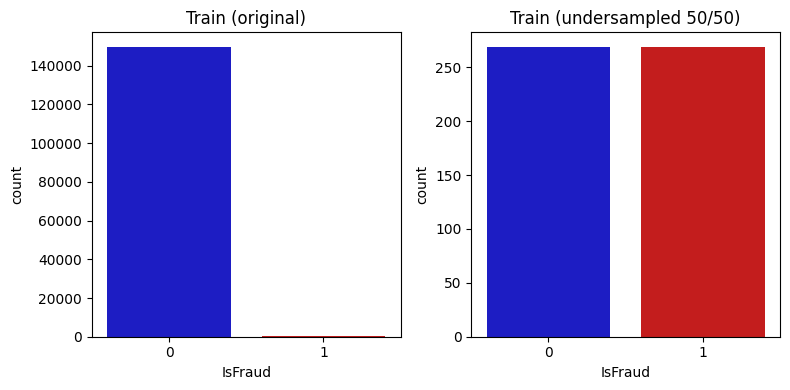

In [56]:
colors = ["#0101DF", "#DF0101"] # Fraud / non Fraud count plot colors

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
sns.countplot(x='IsFraud', data=df_train, palette=colors)
plt.title('Train (original)')

plt.subplot(1,2,2)
sns.countplot(x='IsFraud', data=df_balanced_undersample, palette=colors)
plt.title('Train (undersampled 50/50)')

plt.tight_layout()

Now lets take a look at a correlation matrixes for the undersample and the full dataframe

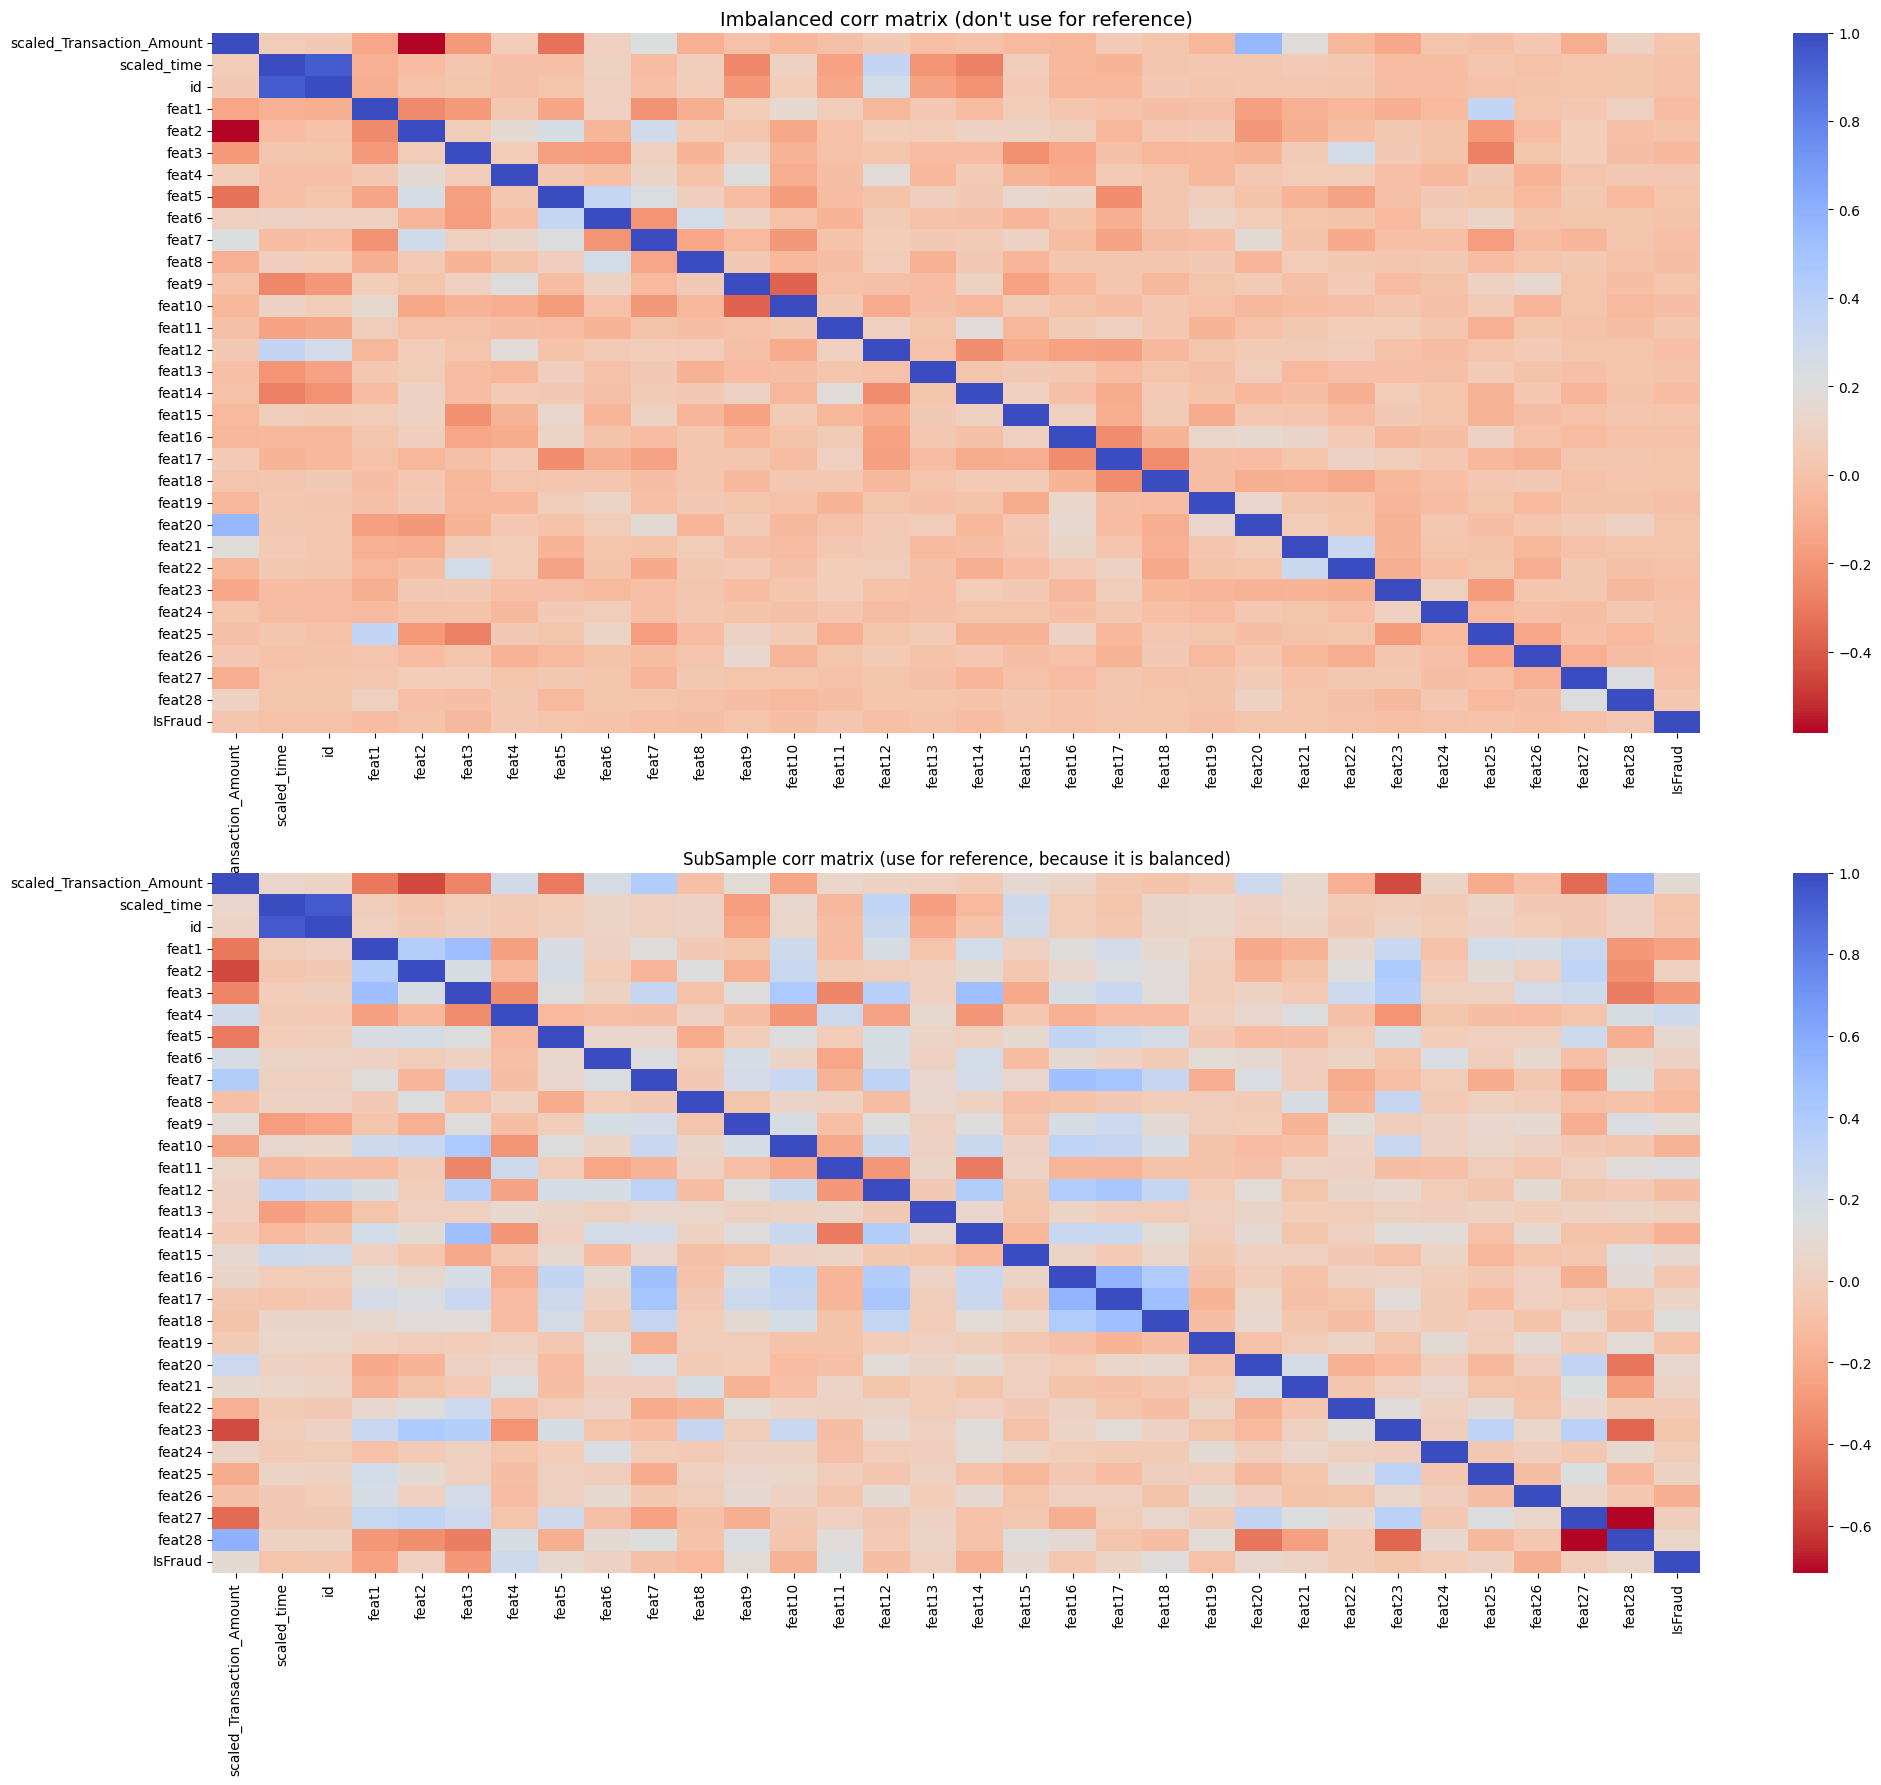

In [57]:
# now lets look at corr matrix for the new and old df (full)
f, (ax1, ax2) = plt.subplots(2,1,figsize=(24,20))

corr = df_train.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title("Imbalanced corr matrix (don't use for reference)", fontsize=14)

sub_sample_corr = df_balanced_undersample.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax2)
ax2.set_title("SubSample corr matrix (use for reference, because it is balanced)")
plt.show()

We see only few features which negatively correlates with isFraud column: feat1, feat3, feat26


C:\Users\tinew\AppData\Local\Temp\ipykernel_10288\3131961205.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat1', data=df_balanced_undersample, palette=colors, ax=axes[0])
C:\Users\tinew\AppData\Local\Temp\ipykernel_10288\3131961205.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat3', data=df_balanced_undersample, palette=colors, ax=axes[1])
C:\Users\tinew\AppData\Local\Temp\ipykernel_10288\3131961205.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat26', data=df_balanced_u

Text(0.5, 1.0, 'feat19 vs class negative corr')

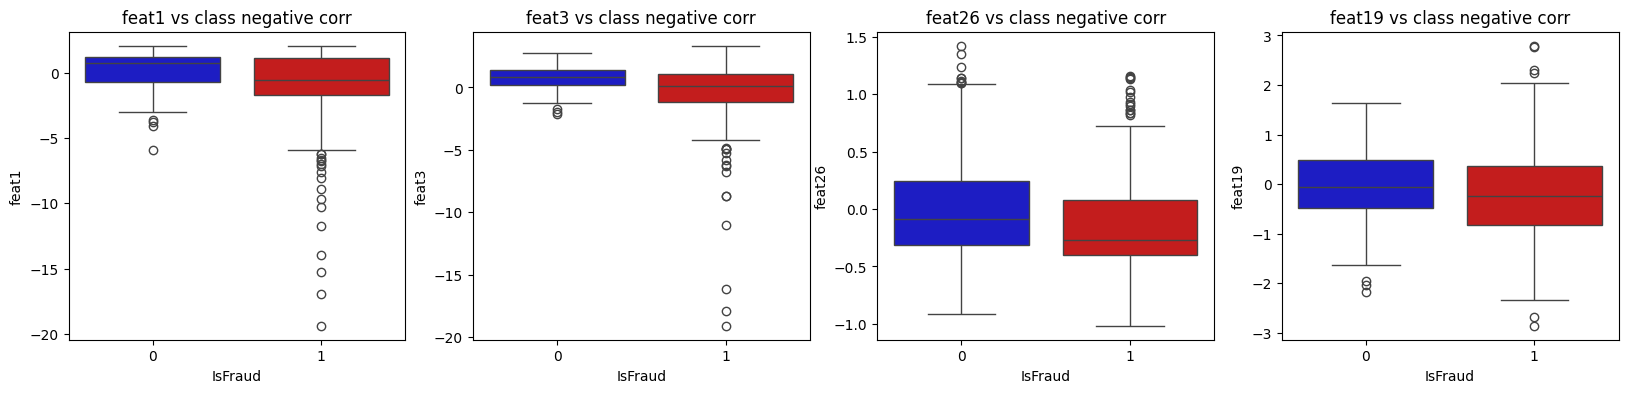

In [58]:
# boxplots for most interested features from the corr matrix
f, axes = plt.subplots(ncols=4, figsize=(20,4))

sns.boxplot(x='IsFraud', y='feat1', data=df_balanced_undersample, palette=colors, ax=axes[0])
axes[0].set_title('feat1 vs class negative corr')

sns.boxplot(x='IsFraud', y='feat3', data=df_balanced_undersample, palette=colors, ax=axes[1])
axes[1].set_title('feat3 vs class negative corr')

sns.boxplot(x='IsFraud', y='feat26', data=df_balanced_undersample, palette=colors, ax=axes[2])
axes[2].set_title('feat26 vs class negative corr')

sns.boxplot(x='IsFraud', y='feat19', data=df_balanced_undersample, palette=colors, ax=axes[3])
axes[3].set_title('feat19 vs class negative corr')




We see only few features which positive correlates with isFraud column: feat4 , feat11, feat18, feat15


C:\Users\tinew\AppData\Local\Temp\ipykernel_10288\349368425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat4', data=df_balanced_undersample, palette=colors, ax=axes[0])
C:\Users\tinew\AppData\Local\Temp\ipykernel_10288\349368425.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat11', data=df_balanced_undersample, palette=colors, ax=axes[1])
C:\Users\tinew\AppData\Local\Temp\ipykernel_10288\349368425.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat18', data=df_balanced_und

Text(0.5, 1.0, 'feat15 vs class positive corr')

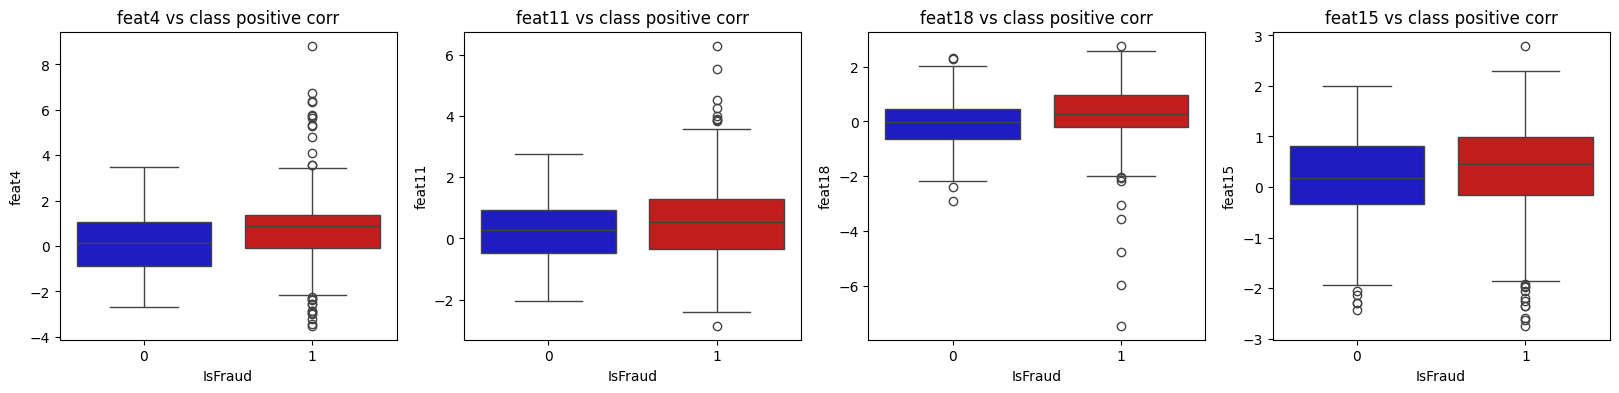

In [59]:
# boxplots for most interested features from the corr matrix
f, axes = plt.subplots(ncols=4, figsize=(20,4))

sns.boxplot(x='IsFraud', y='feat4', data=df_balanced_undersample, palette=colors, ax=axes[0])
axes[0].set_title('feat4 vs class positive corr')

sns.boxplot(x='IsFraud', y='feat11', data=df_balanced_undersample, palette=colors, ax=axes[1])
axes[1].set_title('feat11 vs class positive corr')

sns.boxplot(x='IsFraud', y='feat18', data=df_balanced_undersample, palette=colors, ax=axes[2])
axes[2].set_title('feat18 vs class positive corr')

sns.boxplot(x='IsFraud', y='feat15', data=df_balanced_undersample, palette=colors, ax=axes[3])
axes[3].set_title('feat15 vs class positive corr')

We see a small differences in the correllated features, nothing outstanding. So, just continue modeling with all the features.

In [60]:
# Split X and y
# df_balanced_undersample = df_balanced_undersample.copy()
y_balanced_undersample = df_balanced_undersample['IsFraud']
# X_balanced_undersample = df_balanced_undersample.drop(columns=['id'])
X_balanced_undersample = df_balanced_undersample.drop(columns=['IsFraud','id'])

Lets take a look at a feature importance from Mutual Information perspective.

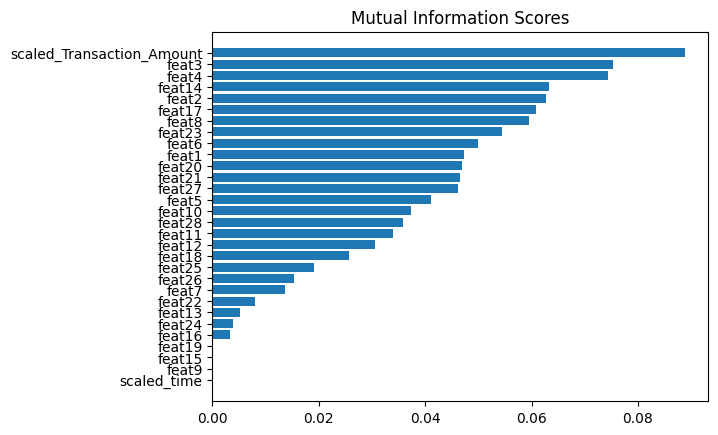

In [61]:
def make_mi_scores(X,y):
    X = X.copy()
    for colname in X.select_dtypes(['object', 'category']):
        x[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_classif(X,y, discrete_features = discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name='MI Scores', index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

def plot_mi_scores(scores):
    '''Input: pandas series from def make_mi_scores'''
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title('Mutual Information Scores')

mi_scores = make_mi_scores(X_balanced_undersample,y_balanced_undersample)
plot_mi_scores(mi_scores)

That could help us to drop features with low MI score if we will need it in future. But now we just use all of them.

# Model comparison

Here we will test and choose the best classifier for balanced undersample

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X_balanced_undersample, y_balanced_undersample, test_size = 0.2, random_state=SEED)

In [63]:
# Values into arrays for feeding the classification algorithms
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [64]:
# Implement simple classifiers
classifiers = {
    "LogisticRegression" : LogisticRegression(random_state=SEED),
    "KNearest" : KNeighborsClassifier(),
    "Support Vector Classifier" : SVC(random_state=SEED),
    "DecisionTreeClassifier" : DecisionTreeClassifier(random_state=SEED),
    "Random Forest" : RandomForestClassifier(random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators = 400, max_depth = 3, learning_rate = 0.01, random_state=SEED
    ),
    "Neural Network" : MLPClassifier(
                                hidden_layer_sizes=(50,50),
                                activation='relu',
                                solver='adam',
                                alpha=1e-3,
                                learning_rate_init=1e-3,
                                early_stopping=True,
                                validation_fraction=0.1,
                                max_iter=500,
                                random_state=SEED
                            )
}

for key, classifier in classifiers.items():
    # classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print("Classifiers:", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2)*100, "% accuracy score")
print("-------------------------")
for key, classifier in classifiers.items():
    # classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5, scoring='average_precision')
    print("Classifiers:", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2)*100, "average_precision")

Classifiers: LogisticRegression Has a training score of 68.0 % accuracy score
Classifiers: KNeighborsClassifier Has a training score of 66.0 % accuracy score
Classifiers: SVC Has a training score of 71.0 % accuracy score
Classifiers: DecisionTreeClassifier Has a training score of 62.0 % accuracy score
Classifiers: RandomForestClassifier Has a training score of 69.0 % accuracy score
Classifiers: GradientBoostingClassifier Has a training score of 66.0 % accuracy score
Classifiers: MLPClassifier Has a training score of 69.0 % accuracy score
-------------------------
Classifiers: LogisticRegression Has a training score of 81.0 average_precision
Classifiers: KNeighborsClassifier Has a training score of 71.0 average_precision
Classifiers: SVC Has a training score of 81.0 average_precision
Classifiers: DecisionTreeClassifier Has a training score of 57.99999999999999 average_precision
Classifiers: RandomForestClassifier Has a training score of 80.0 average_precision
Classifiers: GradientBoosti

We choose the RandomForestClassifier since high level average_precision, accuracy, simplicity and performance. SVC also looks interesting.

In [ ]:
# fit model
model = RandomForestClassifier(n_estimators=400, random_state=SEED)
model.fit(X_train,y_train)

# predictions for validation set
preds = model.predict(X_test)

In [66]:
# Detaiiled precision/recall/F1 by class:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.70      0.78      0.74        55
           1       0.74      0.66      0.70        53

    accuracy                           0.72       108
   macro avg       0.72      0.72      0.72       108
weighted avg       0.72      0.72      0.72       108



In [67]:
# 2) ROC AUC for overall separability
probs = model.predict_proba(X_test)[:,1]
print('ROC AUC:', roc_auc_score(y_test, probs))

ROC AUC: 0.7939965694682676


In [68]:
# 3) Precision-Recall AUC (more informative when positives are rare):
precision, recall, _ = precision_recall_curve(y_test, probs)
print('PR AUC', auc(recall, precision))

PR AUC 0.8001266500209733


<function matplotlib.pyplot.show(close=None, block=None)>

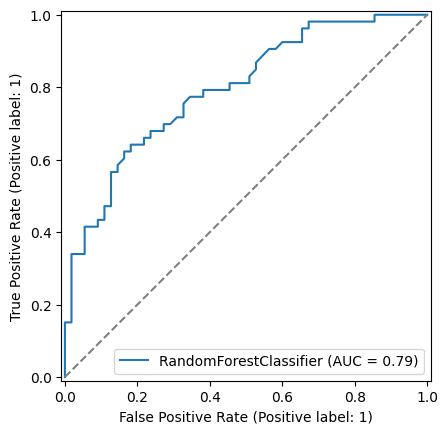

In [69]:
disp = RocCurveDisplay.from_estimator(
    model, X_test, y_test,
    # name=f'ROC (AUC = {roc_auc:.3f})'
)
plt.plot([0,1],[0,1],'--',color='gray')
plt.show

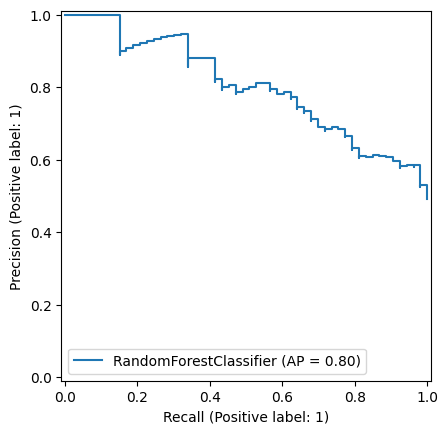

In [70]:
disp2 = PrecisionRecallDisplay.from_estimator(
    model, X_test, y_test,
)
plt.show()

# Submission

In [78]:
submission_data = pd.read_csv('../data/test.csv').drop('id', axis=1)


In [ ]:
# Scaling Time and amount values.

submission_data['scaled_Transaction_Amount'] = rob_scaler.transform(submission_data['Transaction_Amount'].values.reshape(-1,1))
submission_data['scaled_time'] = stnd_scaler.transform(submission_data['Time'].values.reshape(-1,1))

submission_data.drop(['Time','Transaction_Amount'], axis=1, inplace = True)

In [80]:
preds_for_submission = model.predict_proba(submission_data)

c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [75]:
output = pd.DataFrame(
    {
        'id' : submission_data.id,
        'IsFraud' : preds_for_submission[:,1]
    }
)
output.to_csv('submission.csv', index=False)
output

,id,IsFraud
0,150000,0.3950
1,150001,0.3550
2,150002,0.5650
3,150003,0.5825
4,150004,0.4975
...,...,...
69124,219124,0.5450
69125,219125,0.5975
69126,219126,0.5050
69127,219127,0.5750


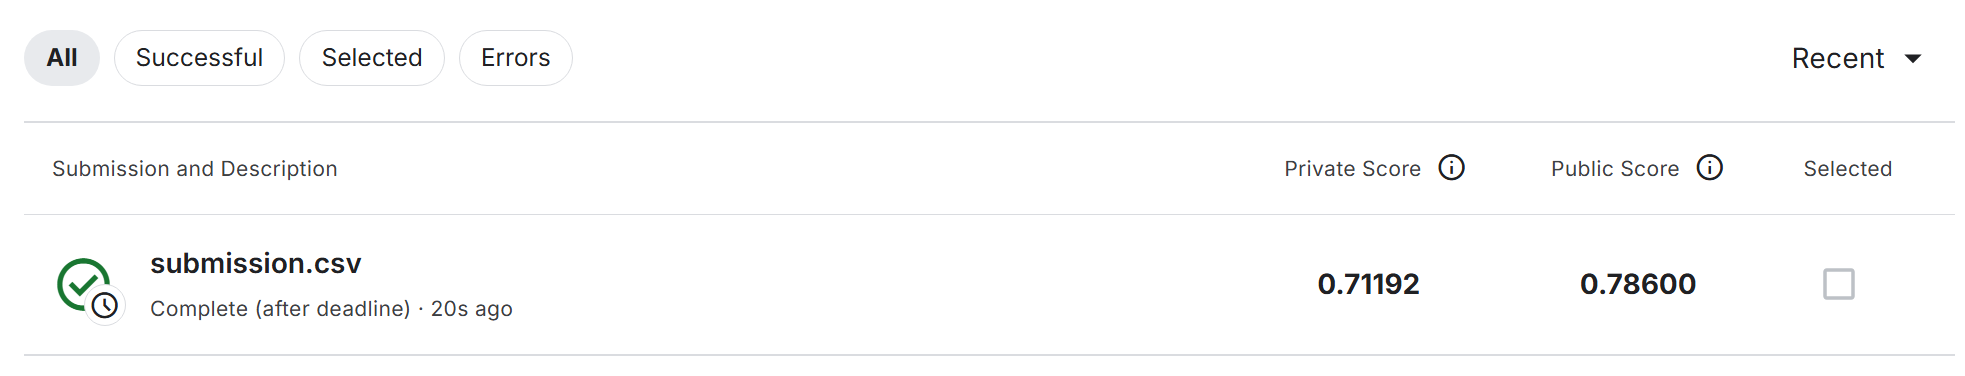

private score 71.1192 public score 0.78600